# Parametric black-box convergence for the 1D Gaussian mechanism

This notebook is the **updated** version aligned with the white-box audit setting.

## Goal

Compare:

- the **exact white-box** privacy curve
  \[
  \delta_{\mathrm{true}}(\varepsilon),
  \]
  obtained from the known Gaussian mechanism parameters,

against

- the **parametric black-box** plug-in estimate
  \[
  \widehat\delta(\varepsilon),
  \]
  obtained by:
  1. sampling from the two neighboring output distributions,
  2. estimating the Gaussian mean and variance on each side,
  3. plugging the fitted parameters into the general 1D Gaussian-pair formula.

## Design

This notebook uses the **same baseline configuration as the white-box audit notebook**:

- query gap = 1,
- target privacy point \((\varepsilon_0, \delta_0) = (1, 10^{-5})\),
- the true noise scale is calibrated exactly from that target,
- the true neighboring pair is
  \[
  X \sim \mathcal N(\mu_1, \sigma^2), \qquad
  Y \sim \mathcal N(\mu_2, \sigma^2),
  \]
  with \(|\mu_2-\mu_1| = 1\).

## Outputs

1. A **3-panel convergence figure** on the \(\varepsilon\)-\(\delta\) scale for
   \(n \in \{10^3, 10^4, 10^5\}\):
   - exact white-box curve,
   - parametric black-box estimated curve,
   - pointwise 95% bootstrap ribbon.

2. A summary table with:
   - fitted Gaussian parameters,
   - pointwise estimate at \(\varepsilon_0\),
   - 95% bootstrap interval at \(\varepsilon_0\),
   - whether the interval contains the true value.

3. An optional repeated-sampling study of:
   - median absolute error,
   - RMSE,
   - empirical pointwise 95% coverage,
   - median interval width.

## Important note

The ribbon shown for the full curve is a **pointwise 95% bootstrap band** at each
\(\varepsilon\) on the grid. It is **not** a simultaneous 95% confidence band for the
entire curve.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from scipy.optimize import brentq
from scipy.stats import norm

pd.set_option("display.float_format", lambda x: f"{x:.6g}")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


## Configuration

You can edit this cell and rerun the notebook.


In [2]:
# ------------------------------------------------------------
# White-box-aligned baseline configuration
# ------------------------------------------------------------
QUERY_GAP_L2 = 1.0
EPSILON0 = 1.0
DELTA0 = 1e-5

# We use the same neighboring-pair convention as the white-box notebook:
# mu1 = 0, mu2 = query gap.
MU1_TRUE = 0.0
MU2_TRUE = QUERY_GAP_L2

# Sample sizes for the convergence figure
N_VALUES = [10**3, 10**4, 10**5]

# Epsilon grid for the delta-curves
EPS_GRID = np.linspace(0.01, 5.0, 160)

# Bootstrap settings
BOOTSTRAP_B_CURVE = 150   # pointwise ribbon on the epsilon-delta curve
BOOTSTRAP_B_POINT = 300   # interval for delta(epsilon0)
GAMMA = 0.05              # 95% intervals

# Optional repeated-sampling study
RUN_REPEATED_STUDY = True
REPEATED_TRIALS = 40

RNG_SEED = 11

# The Gaussian mechanism uses the same noise variance on both neighboring datasets.
# Pooling the two variance estimates lowers estimator variance at the same sample size.
USE_POOLED_VARIANCE = True


## Equal-variance Gaussian mechanism formulas


In [3]:
def delta_equal_variance(epsilon, mu):
    '''
    Exact delta(epsilon) for the standard 1D Gaussian mechanism in the equal-variance case,
    parameterized by mu = |mu2 - mu1| / sigma.
    '''
    epsilon = np.asarray(epsilon, dtype=float)
    if np.isclose(mu, 0.0):
        return np.zeros_like(epsilon, dtype=float)
    a = -epsilon / mu + mu / 2.0
    b = -epsilon / mu - mu / 2.0
    out = norm.cdf(a) - np.exp(epsilon) * norm.cdf(b)
    return np.maximum(out, 0.0)


def calibrate_sigma_for_target(epsilon0, delta0, query_gap_l2, sigma_lower=1e-9, sigma_upper=1e6):
    '''
    Solve for sigma such that delta(epsilon0) = delta0 in the equal-variance Gaussian mechanism.
    '''
    if not (0 <= delta0 < 1):
        raise ValueError("delta0 must be in [0,1).")
    if epsilon0 < 0:
        raise ValueError("epsilon0 must be nonnegative.")
    if query_gap_l2 <= 0:
        raise ValueError("query_gap_l2 must be positive.")

    def f(sig):
        mu = query_gap_l2 / sig
        return float(delta_equal_variance(epsilon0, mu) - delta0)

    lo, hi = sigma_lower, sigma_upper
    flo, fhi = f(lo), f(hi)

    if flo < 0:
        raise RuntimeError("Lower sigma bracket is already below the target.")
    while fhi > 0:
        hi *= 10.0
        if hi > 1e18:
            raise RuntimeError("Could not bracket the root.")
        fhi = f(hi)

    return brentq(f, lo, hi, maxiter=1000)


SIGMA_TRUE = calibrate_sigma_for_target(EPSILON0, DELTA0, QUERY_GAP_L2)
MU_TRUE = abs(MU2_TRUE - MU1_TRUE) / SIGMA_TRUE

print(f"query gap           = {QUERY_GAP_L2:.6g}")
print(f"target epsilon0     = {EPSILON0:.6g}")
print(f"target delta0       = {DELTA0:.6g}")
print(f"calibrated sigma    = {SIGMA_TRUE:.6g}")
print(f"true Gaussian mu    = {MU_TRUE:.6g}")


query gap           = 1
target epsilon0     = 1
target delta0       = 1e-05
calibrated sigma    = 3.73063
true Gaussian mu    = 0.268051


## General 1D Gaussian-pair plug-in formulas

The parametric black-box estimator fits
\[
\widehat X \sim \mathcal N(\hat\mu_1, \hat\sigma_1^2), \qquad
\widehat Y \sim \mathcal N(\hat\mu_2, \hat\sigma_2^2),
\]
then computes \(\widehat\delta(\varepsilon)\) using the exact 1D Gaussian-pair closed form.

The ordered-variance lemma applies directly when the first distribution has the smaller variance. If the fitted variances land in the opposite order, swapping the two distributions lets us apply the same lemma to the reverse direction. Since DP requires both neighboring directions, the plug-in curve below reports the larger of \(\delta_{X,Y}(\varepsilon)\) and \(\delta_{Y,X}(\varepsilon)\). For the original direction with \(\sigma_1^2 > \sigma_2^2\), the code also keeps the complementary outside-interval calculation; a bare swap alone would change the direction being evaluated.


In [4]:
def fit_gaussian_1d(samples):
    '''
    Fit a 1D Gaussian by sample mean and sample standard deviation.
    '''
    samples = np.asarray(samples, dtype=float)
    mean = float(np.mean(samples))
    std = float(np.std(samples, ddof=1))
    return mean, max(std, 1e-12)



def fit_gaussian_pair_1d(x, y, use_pooled_variance=USE_POOLED_VARIANCE):
    '''
    Fit the two Gaussian marginals.

    If use_pooled_variance is True, impose the Gaussian-mechanism structure
    sigma1^2 = sigma2^2 and use the pooled sample variance.
    '''
    mu1_hat, sigma1_hat = fit_gaussian_1d(x)
    mu2_hat, sigma2_hat = fit_gaussian_1d(y)

    if not use_pooled_variance:
        return mu1_hat, sigma1_hat, mu2_hat, sigma2_hat

    n1 = len(x)
    n2 = len(y)
    if n1 + n2 <= 2:
        sigma_hat = max(float(np.sqrt(0.5 * (sigma1_hat**2 + sigma2_hat**2))), 1e-12)
    else:
        pooled_var = ((n1 - 1) * sigma1_hat**2 + (n2 - 1) * sigma2_hat**2) / (n1 + n2 - 2)
        sigma_hat = max(float(np.sqrt(pooled_var)), 1e-12)

    return mu1_hat, sigma_hat, mu2_hat, sigma_hat

def _prob_region_normal(mu, sigma, region):
    '''
    Probability that N(mu, sigma^2) lies in a region encoded as:
      ('all',)
      ('none',)
      ('lt', x0)
      ('gt', x0)
      ('inside', left, right)
      ('outside', left, right)
    '''
    kind = region[0]
    if kind == 'all':
        return 1.0
    if kind == 'none':
        return 0.0
    if kind == 'lt':
        x0 = region[1]
        return norm.cdf((x0 - mu) / sigma)
    if kind == 'gt':
        x0 = region[1]
        return 1.0 - norm.cdf((x0 - mu) / sigma)
    if kind == 'inside':
        left, right = region[1], region[2]
        z_left = (left - mu) / sigma
        z_right = (right - mu) / sigma
        return norm.cdf(z_right) - norm.cdf(z_left)
    if kind == 'outside':
        left, right = region[1], region[2]
        z_left = (left - mu) / sigma
        z_right = (right - mu) / sigma
        return norm.cdf(z_left) + (1.0 - norm.cdf(z_right))
    raise ValueError(f'Unknown region type: {kind}')


def _quadratic_region_gt(A, B, C, tol=1e-12):
    '''
    Solve A x^2 + B x + C > 0 and return a region encoding.
    Kept for alpha/beta tradeoff diagnostics; delta uses the closed form below.
    '''
    if abs(A) < tol:
        if abs(B) < tol:
            return ('all',) if C > 0 else ('none',)
        x0 = -C / B
        return ('gt', x0) if B > 0 else ('lt', x0)

    disc = B * B - 4.0 * A * C
    if disc < -tol:
        return ('all',) if A > 0 else ('none',)
    disc = max(disc, 0.0)
    sqrt_disc = np.sqrt(disc)
    r1 = (-B - sqrt_disc) / (2.0 * A)
    r2 = (-B + sqrt_disc) / (2.0 * A)
    left, right = sorted([r1, r2])

    if A > 0:
        return ('outside', left, right)
    return ('inside', left, right)


def alpha_beta_from_threshold_1d(mu1, sigma1, mu2, sigma2, eta):
    '''
    For p = N(mu1, sigma1^2), q = N(mu2, sigma2^2),
    compute the Neyman-Pearson point (alpha(eta), beta(eta))
    for the rejection region q/p > eta.
    '''
    if eta <= 0:
        raise ValueError('eta must be positive.')

    A = 1.0 / (2.0 * sigma1**2) - 1.0 / (2.0 * sigma2**2)
    B = -mu1 / (sigma1**2) + mu2 / (sigma2**2)
    C = (
        mu1**2 / (2.0 * sigma1**2)
        - mu2**2 / (2.0 * sigma2**2)
        + np.log(sigma1 / sigma2)
        - np.log(eta)
    )

    region = _quadratic_region_gt(A, B, C)
    alpha = _prob_region_normal(mu1, sigma1, region)
    beta = 1.0 - _prob_region_normal(mu2, sigma2, region)
    return float(alpha), float(beta), region


def _delta_ordered_lemma_scalar(epsilon, mu_small, sigma_small, mu_large, sigma_large):
    '''
    Lemma branch for delta_{small,large}(epsilon), requiring sigma_small^2 < sigma_large^2.
    '''
    if not (sigma_small**2 < sigma_large**2):
        raise ValueError('The ordered lemma requires sigma_small^2 < sigma_large^2.')

    tau = sigma_small**2 / sigma_large**2
    a = 1.0 - tau
    b = -sigma_small * (mu_small - mu_large) / (sigma_large**2)
    c = epsilon + 0.5 * np.log(tau) - ((mu_small - mu_large) ** 2) / (2.0 * sigma_large**2)
    D = b * b - 2.0 * a * c

    if D <= 0:
        return 0.0

    sqrt_D = np.sqrt(D)
    z_minus = (-b - sqrt_D) / a
    z_plus = (-b + sqrt_D) / a
    m = -(mu_small - mu_large) / sigma_small

    term1 = norm.cdf(z_plus) - norm.cdf(z_minus)
    term2 = norm.cdf((z_plus - m) * np.sqrt(tau)) - norm.cdf((z_minus - m) * np.sqrt(tau))
    return max(float(term1 - np.exp(epsilon) * term2), 0.0)


def _delta_one_direction_scalar(epsilon, mu1, sigma1, mu2, sigma2):
    '''
    Exact one-direction delta_{X,Y}(epsilon).

    If sigma1^2 > sigma2^2, directly swapping X and Y would compute delta_{Y,X}.
    To preserve the original direction, use the complementary outside interval.
    '''
    if epsilon < 0:
        raise ValueError('epsilon must be nonnegative.')
    if sigma1 <= 0 or sigma2 <= 0:
        raise ValueError('sigma1 and sigma2 must be positive.')

    var1 = sigma1**2
    var2 = sigma2**2
    if np.isclose(var1, var2, rtol=1e-10, atol=1e-14):
        sigma = np.sqrt(0.5 * (var1 + var2))
        mu = abs(mu2 - mu1) / sigma
        return float(delta_equal_variance(np.array([epsilon]), mu)[0])

    if var1 < var2:
        return _delta_ordered_lemma_scalar(epsilon, mu1, sigma1, mu2, sigma2)

    tau = var1 / var2
    a = 1.0 - tau
    b = -sigma1 * (mu1 - mu2) / var2
    c = epsilon + 0.5 * np.log(tau) - ((mu1 - mu2) ** 2) / (2.0 * var2)
    D = b * b - 2.0 * a * c

    if D <= 0:
        return 0.0

    sqrt_D = np.sqrt(D)
    z_left, z_right = sorted(((-b - sqrt_D) / a, (-b + sqrt_D) / a))
    m = -(mu1 - mu2) / sigma1
    sqrt_tau = np.sqrt(tau)

    px_inside = norm.cdf(z_right) - norm.cdf(z_left)
    py_inside = norm.cdf((z_right - m) * sqrt_tau) - norm.cdf((z_left - m) * sqrt_tau)

    px_region = 1.0 - px_inside
    py_region = 1.0 - py_inside
    val = px_region - np.exp(epsilon) * py_region
    return max(float(val), 0.0)


def _delta_two_sided_scalar(epsilon, mu1, sigma1, mu2, sigma2):
    '''
    DP-relevant pairwise delta: max(delta_{X,Y}, delta_{Y,X}).
    The reverse direction reuses the lemma by swapping roles when sigma2^2 < sigma1^2.
    '''
    forward = _delta_one_direction_scalar(epsilon, mu1, sigma1, mu2, sigma2)
    reverse = _delta_one_direction_scalar(epsilon, mu2, sigma2, mu1, sigma1)
    return max(forward, reverse)


def delta_general_1d_from_lr(epsilon, mu1, sigma1, mu2, sigma2):
    '''
    Exact two-sided pairwise delta(epsilon) for a 1D Gaussian pair.

    This reports the DP-relevant max of the two neighboring directions. The name
    is kept for compatibility with the rest of the notebook.
    '''
    epsilon = np.asarray(epsilon, dtype=float)
    out = np.empty_like(epsilon, dtype=float)

    for index, eps in np.ndenumerate(epsilon):
        out[index] = _delta_two_sided_scalar(float(eps), mu1, sigma1, mu2, sigma2)

    return out


def delta_1d_closed_form_ordered(epsilon, mu1, sigma1, mu2, sigma2):
    '''
    Closed-form branch from the 1D lemma, valid when sigma1^2 < sigma2^2.
    '''
    return _delta_ordered_lemma_scalar(epsilon, mu1, sigma1, mu2, sigma2)


# Sanity checks.
example_eps = 1.0
example = dict(mu1=0.0, sigma1=0.8, mu2=1.0, sigma2=1.2)
eta = np.exp(-example_eps)
alpha_eta, beta_eta, _ = alpha_beta_from_threshold_1d(**example, eta=eta)
delta_region = max(float((1.0 - alpha_eta) - np.exp(example_eps) * beta_eta), 0.0)
delta_cf = delta_1d_closed_form_ordered(example_eps, **example)
example_swapped = dict(mu1=0.0, sigma1=1.2, mu2=1.0, sigma2=0.8)
delta_swapped_role = delta_1d_closed_form_ordered(
    example_eps,
    example_swapped['mu2'],
    example_swapped['sigma2'],
    example_swapped['mu1'],
    example_swapped['sigma1'],
)
print('Closed-form ordered-variance checks:')
print(f'  direct lemma vs LR-region diff = {abs(delta_region - delta_cf):.3e}')
print(f'  swapped-role lemma value       = {delta_swapped_role:.8f}')


Closed-form ordered-variance checks:
  direct lemma vs LR-region diff = 5.551e-17
  swapped-role lemma value       = 0.00321545


## Bootstrap routines


In [5]:
def bootstrap_delta_curve(x, y, eps_grid, B=150, seed=0):
    '''
    Parametric bootstrap for the full epsilon-delta curve.
    Returns:
        lower, upper, curves
    where lower/upper are pointwise percentile bands and curves is the bootstrap matrix.
    '''
    rng = np.random.default_rng(seed)

    mu1_hat, sigma1_hat, mu2_hat, sigma2_hat = fit_gaussian_pair_1d(x, y)

    n = len(x)
    curves = np.empty((B, len(eps_grid)), dtype=float)

    for b in range(B):
        xb = rng.normal(mu1_hat, sigma1_hat, size=n)
        yb = rng.normal(mu2_hat, sigma2_hat, size=n)

        mu1_b, sigma1_b, mu2_b, sigma2_b = fit_gaussian_pair_1d(xb, yb)

        curves[b, :] = delta_general_1d_from_lr(eps_grid, mu1_b, sigma1_b, mu2_b, sigma2_b)

    lo = np.quantile(curves, GAMMA / 2.0, axis=0)
    hi = np.quantile(curves, 1.0 - GAMMA / 2.0, axis=0)
    return lo, hi, curves


def bootstrap_delta_point_interval(x, y, epsilon0, B=300, seed=0):
    '''
    Parametric bootstrap percentile interval for delta(epsilon0).
    '''
    rng = np.random.default_rng(seed)

    mu1_hat, sigma1_hat, mu2_hat, sigma2_hat = fit_gaussian_pair_1d(x, y)

    n = len(x)
    delta_boot = np.empty(B, dtype=float)

    for b in range(B):
        xb = rng.normal(mu1_hat, sigma1_hat, size=n)
        yb = rng.normal(mu2_hat, sigma2_hat, size=n)

        mu1_b, sigma1_b, mu2_b, sigma2_b = fit_gaussian_pair_1d(xb, yb)

        delta_boot[b] = delta_general_1d_from_lr(
            np.array([epsilon0]), mu1_b, sigma1_b, mu2_b, sigma2_b
        )[0]

    lo, hi = np.quantile(delta_boot, [GAMMA / 2.0, 1.0 - GAMMA / 2.0])
    return float(lo), float(hi), delta_boot


## Single-run convergence panels


In [ ]:
@dataclass
class CurvePanelResult:
    n: int
    mu1_hat: float
    sigma1_hat: float
    mu2_hat: float
    sigma2_hat: float
    delta_true_eps0: float
    delta_hat_eps0: float
    delta_ci_lo: float
    delta_ci_hi: float
    delta_conservative_eps0: float
    conservative_decision: str
    delta_ci_contains_truth: bool
    true_curve: np.ndarray
    hat_curve: np.ndarray
    curve_lo: np.ndarray
    curve_hi: np.ndarray


def run_curve_panel(n, seed=0):
    rng = np.random.default_rng(seed)

    x = rng.normal(MU1_TRUE, SIGMA_TRUE, size=n)
    y = rng.normal(MU2_TRUE, SIGMA_TRUE, size=n)

    mu1_hat, sigma1_hat, mu2_hat, sigma2_hat = fit_gaussian_pair_1d(x, y)

    true_curve = delta_equal_variance(EPS_GRID, MU_TRUE)
    hat_curve = delta_general_1d_from_lr(EPS_GRID, mu1_hat, sigma1_hat, mu2_hat, sigma2_hat)

    curve_lo, curve_hi, _ = bootstrap_delta_curve(
        x, y, EPS_GRID, B=BOOTSTRAP_B_CURVE, seed=seed + 1000
    )

    delta_true_eps0 = float(delta_equal_variance(np.array([EPSILON0]), MU_TRUE)[0])
    delta_hat_eps0 = float(
        delta_general_1d_from_lr(np.array([EPSILON0]), mu1_hat, sigma1_hat, mu2_hat, sigma2_hat)[0]
    )

    delta_ci_lo, delta_ci_hi, _ = bootstrap_delta_point_interval(
        x, y, EPSILON0, B=BOOTSTRAP_B_POINT, seed=seed + 2000
    )
    delta_conservative_eps0 = delta_ci_hi
    conservative_decision = (
        'CONSERVATIVE VIOLATION'
        if delta_conservative_eps0 > DELTA0
        else 'NO CONSERVATIVE VIOLATION'
    )

    return CurvePanelResult(
        n=n,
        mu1_hat=mu1_hat,
        sigma1_hat=sigma1_hat,
        mu2_hat=mu2_hat,
        sigma2_hat=sigma2_hat,
        delta_true_eps0=delta_true_eps0,
        delta_hat_eps0=delta_hat_eps0,
        delta_ci_lo=delta_ci_lo,
        delta_ci_hi=delta_ci_hi,
        delta_conservative_eps0=delta_conservative_eps0,
        conservative_decision=conservative_decision,
        delta_ci_contains_truth=(delta_ci_lo <= delta_true_eps0 <= delta_ci_hi),
        true_curve=true_curve,
        hat_curve=hat_curve,
        curve_lo=curve_lo,
        curve_hi=curve_hi,
    )


panel_results = [run_curve_panel(n=n, seed=RNG_SEED + i) for i, n in enumerate(N_VALUES)]
panel_results


## 3-panel convergence figure on the \(\varepsilon\)-\(\delta\) scale


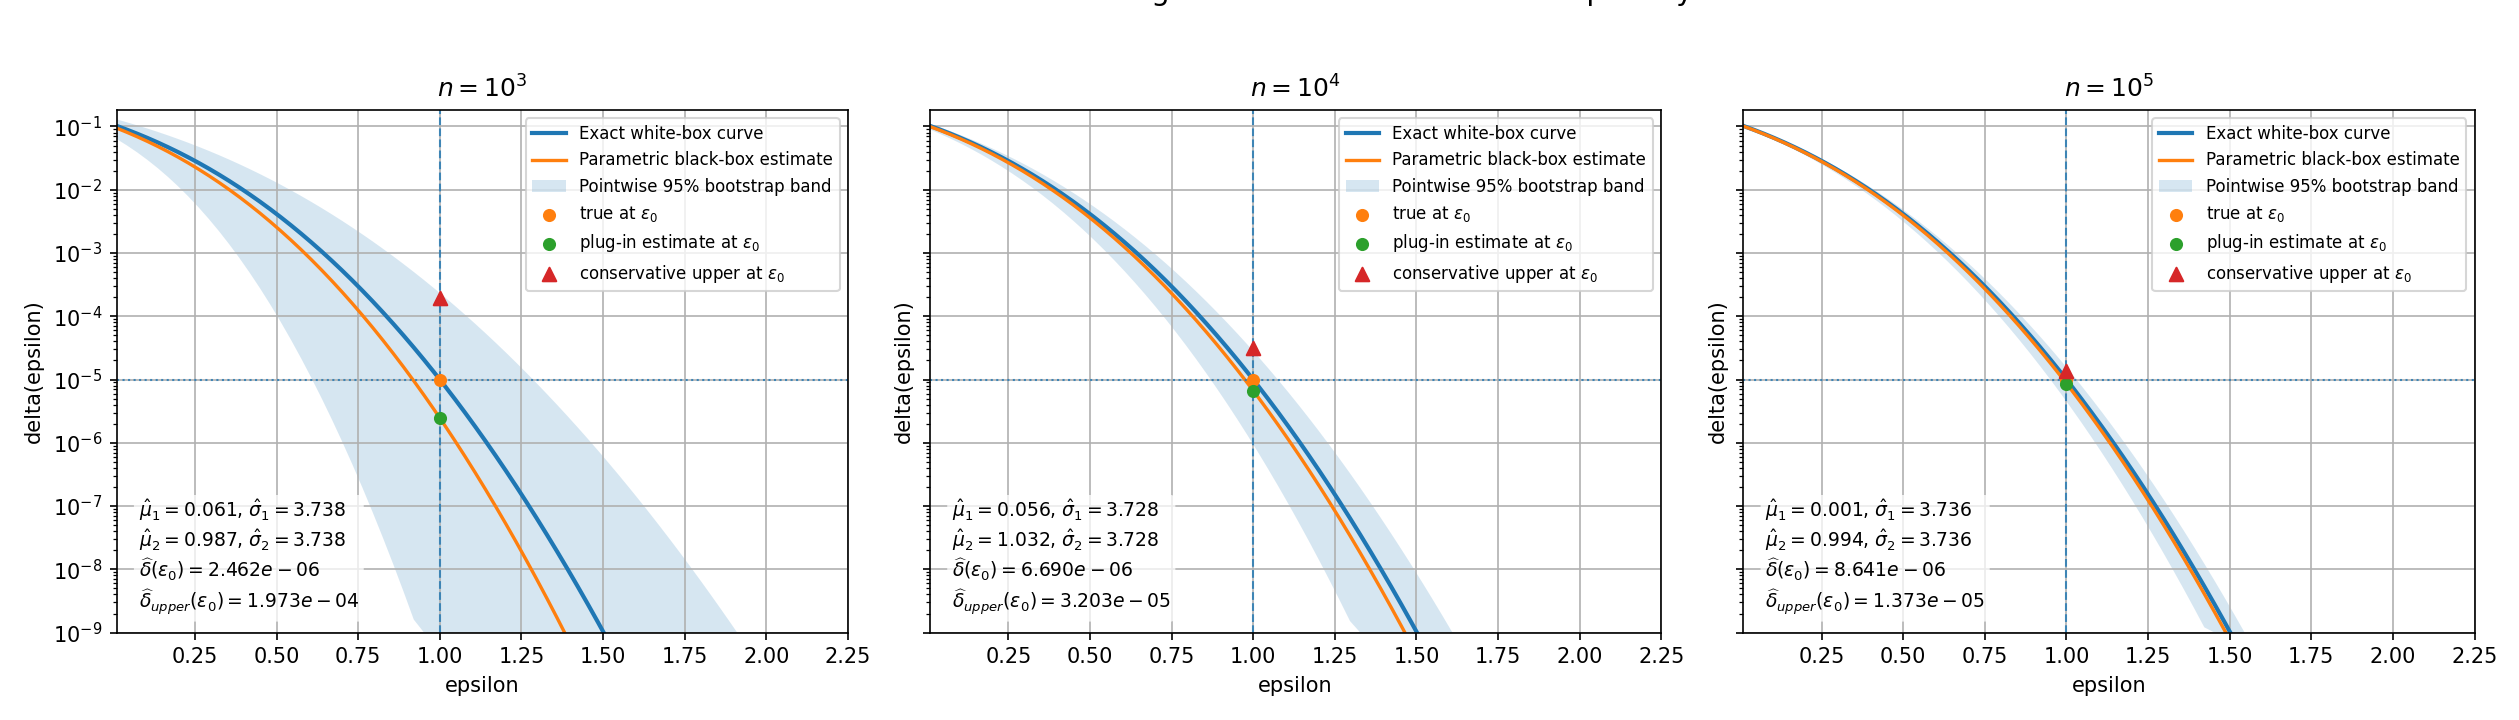

In [7]:
def _positive_for_log(values):
    values = np.asarray(values, dtype=float)
    return np.where(values > 0.0, values, np.nan)


fig, axes = plt.subplots(1, len(panel_results), figsize=(5.6 * len(panel_results), 4.8), sharey=True)

if len(panel_results) == 1:
    axes = [axes]

positive_values = []
for res in panel_results:
    for values in [
        res.true_curve,
        res.hat_curve,
        res.curve_lo,
        res.curve_hi,
        [DELTA0, res.delta_hat_eps0, res.delta_conservative_eps0],
    ]:
        arr = np.asarray(values, dtype=float)
        positive_values.append(arr[arr > 0.0])
positive_values = np.concatenate([v for v in positive_values if v.size])
y_floor = max(np.nanmin(positive_values) / 3.0, DELTA0 / 1e4)
y_ceiling = min(1.0, np.nanmax(positive_values) * 1.4)
x_right = min(EPS_GRID.max(), EPSILON0 + 1.25)

for ax, res in zip(axes, panel_results):
    ax.plot(EPS_GRID, _positive_for_log(res.true_curve), linewidth=2.0, label='Exact white-box curve')
    ax.plot(EPS_GRID, _positive_for_log(res.hat_curve), linewidth=1.6, label='Parametric black-box estimate')

    band_hi = _positive_for_log(res.curve_hi)
    band_lo = np.maximum(res.curve_lo, y_floor)
    ax.fill_between(
        EPS_GRID,
        band_lo,
        band_hi,
        where=np.isfinite(band_hi),
        alpha=0.18,
        label='Pointwise 95% bootstrap band',
    )

    ax.axvline(EPSILON0, linestyle='--', linewidth=1.0, alpha=0.8)
    ax.axhline(DELTA0, linestyle=':', linewidth=1.0, alpha=0.8)
    ax.scatter([EPSILON0], [res.delta_true_eps0], s=28, zorder=4, label=r'true at $\epsilon_0$')
    ax.scatter([EPSILON0], [res.delta_hat_eps0], s=28, zorder=4, label=r'plug-in estimate at $\epsilon_0$')
    ax.scatter(
        [EPSILON0],
        [res.delta_conservative_eps0],
        s=42,
        marker='^',
        zorder=5,
        label=r'conservative upper at $\epsilon_0$',
    )

    ax.set_yscale('log')
    ax.set_xlim(EPS_GRID.min(), x_right)
    ax.set_ylim(y_floor, y_ceiling)
    ax.set_xlabel('epsilon')
    ax.set_ylabel('delta(epsilon)')
    ax.set_title(rf'$n = 10^{{{int(np.log10(res.n))}}}$')

    txt = (
        rf'$\hat{{\mu}}_1={res.mu1_hat:.3f}$, $\hat{{\sigma}}_1={res.sigma1_hat:.3f}$' + '\n'
        rf'$\hat{{\mu}}_2={res.mu2_hat:.3f}$, $\hat{{\sigma}}_2={res.sigma2_hat:.3f}$' + '\n'
        rf'$\widehat{{\delta}}(\epsilon_0)={res.delta_hat_eps0:.3e}$' + '\n'
        rf'$\widehat{{\delta}}_{{upper}}(\epsilon_0)={res.delta_conservative_eps0:.3e}$'
    )
    ax.text(
        0.03, 0.03, txt,
        transform=ax.transAxes,
        ha='left', va='bottom',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.75, edgecolor='none'),
    )

    ax.legend(fontsize=8, loc='upper right')

fig.suptitle(
    'Parametric black-box convergence to the exact white-box privacy curve',
    fontsize=14,
    y=1.03,
)
plt.tight_layout()
plt.show()


## Pointwise summary at \(\varepsilon_0\)

The raw plug-in estimate `delta_hat_at_eps0` is not conservative. For audit-style comparisons, use `delta_conservative_upper_at_eps0`, the upper end of the 95% bootstrap interval.


In [8]:
summary_df = pd.DataFrame(
    [
        {
            'n': res.n,
            'mu1_hat': res.mu1_hat,
            'sigma1_hat': res.sigma1_hat,
            'mu2_hat': res.mu2_hat,
            'sigma2_hat': res.sigma2_hat,
            'delta_true_at_eps0': res.delta_true_eps0,
            'delta_hat_at_eps0': res.delta_hat_eps0,
            'abs_error_at_eps0': abs(res.delta_hat_eps0 - res.delta_true_eps0),
            'delta_ci_lo': res.delta_ci_lo,
            'delta_ci_hi': res.delta_ci_hi,
            'delta_conservative_upper_at_eps0': res.delta_conservative_eps0,
            'conservative_exceeds_delta0': res.delta_conservative_eps0 > DELTA0,
            'conservative_decision': res.conservative_decision,
            'delta_ci_contains_truth': res.delta_ci_contains_truth,
        }
        for res in panel_results
    ]
)
summary_df


,n,mu1_hat,sigma1_hat,mu2_hat,sigma2_hat,delta_true_at_eps0,delta_hat_at_eps0,abs_error_at_eps0,delta_ci_lo,delta_ci_hi,delta_conservative_upper_at_eps0,conservative_exceeds_delta0,conservative_decision,delta_ci_contains_truth
0,1000,0.0610273,3.73828,0.987109,3.73828,1e-05,2.46189e-06,7.53811e-06,6.00521e-12,0.000197343,0.000197343,True,CONSERVATIVE VIOLATION,True
1,10000,0.056317,3.72823,1.03224,3.72823,1e-05,6.68991e-06,3.31009e-06,7.80626e-07,3.20332e-05,3.20332e-05,True,CONSERVATIVE VIOLATION,True
2,100000,0.000849797,3.73591,0.993558,3.73591,1e-05,8.64083e-06,1.35917e-06,4.72522e-06,1.37279e-05,1.37279e-05,True,CONSERVATIVE VIOLATION,True


## Optional repeated-sampling study at \(\varepsilon_0\)

This section measures, as a function of sample size:

- median absolute error,
- RMSE,
- empirical pointwise 95% coverage,
- median interval width.

Set `RUN_REPEATED_STUDY = True` to run it.


In [ ]:
if RUN_REPEATED_STUDY:
    rows = []
    delta_true_eps0 = float(delta_equal_variance(np.array([EPSILON0]), MU_TRUE)[0])

    for j, n in enumerate(N_VALUES):
        for t in range(REPEATED_TRIALS):
            seed = 10000 + 1000 * j + t
            rng = np.random.default_rng(seed)

            x = rng.normal(MU1_TRUE, SIGMA_TRUE, size=n)
            y = rng.normal(MU2_TRUE, SIGMA_TRUE, size=n)

            mu1_hat, sigma1_hat, mu2_hat, sigma2_hat = fit_gaussian_pair_1d(x, y)

            delta_hat = float(
                delta_general_1d_from_lr(np.array([EPSILON0]), mu1_hat, sigma1_hat, mu2_hat, sigma2_hat)[0]
            )
            ci_lo, ci_hi, _ = bootstrap_delta_point_interval(
                x, y, EPSILON0, B=max(150, BOOTSTRAP_B_POINT // 2), seed=seed + 50000
            )

            rows.append(
                {
                    'n': n,
                    'trial': t,
                    'delta_true': delta_true_eps0,
                    'delta_hat': delta_hat,
                    'delta_conservative_upper': ci_hi,
                    'conservative_exceeds_delta0': ci_hi > DELTA0,
                    'abs_error': abs(delta_hat - delta_true_eps0),
                    'sq_error': (delta_hat - delta_true_eps0) ** 2,
                    'contains_truth': ci_lo <= delta_true_eps0 <= ci_hi,
                    'ci_width': ci_hi - ci_lo,
                }
            )

    rep_df = pd.DataFrame(rows)

    rep_summary = (
        rep_df.groupby('n')
        .agg(
            median_abs_error=('abs_error', 'median'),
            rmse=('sq_error', lambda s: np.sqrt(np.mean(s))),
            empirical_coverage=('contains_truth', 'mean'),
            median_ci_width=('ci_width', 'median'),
            median_conservative_upper=('delta_conservative_upper', 'median'),
            conservative_exceeds_delta0_rate=('conservative_exceeds_delta0', 'mean'),
        )
        .reset_index()
    )

    display(rep_summary)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(rep_summary['n'], rep_summary['median_abs_error'], marker='o')
    axes[0].set_xscale('log')
    axes[0].set_title('Median absolute error')
    axes[0].set_xlabel('sample size n')
    axes[0].set_ylabel('error')

    axes[1].plot(rep_summary['n'], rep_summary['median_ci_width'], marker='o')
    axes[1].set_xscale('log')
    axes[1].set_title('Median pointwise 95% interval width')
    axes[1].set_xlabel('sample size n')
    axes[1].set_ylabel('width')

    axes[2].plot(rep_summary['n'], rep_summary['empirical_coverage'], marker='o')
    axes[2].axhline(0.95, linestyle='--', linewidth=1.0)
    axes[2].set_xscale('log')
    axes[2].set_ylim(0, 1.05)
    axes[2].set_title('Empirical pointwise 95% coverage')
    axes[2].set_xlabel('sample size n')
    axes[2].set_ylabel('coverage')

    plt.tight_layout()
    plt.show()
else:
    print('Repeated-sampling study skipped. Set RUN_REPEATED_STUDY = True to run it.')


## Notes

- This notebook is intentionally aligned with the **white-box audit** configuration:
  same query gap, same \((\varepsilon_0, \delta_0)\), same exact true curve.

- The only change is the information model:
  - **white-box**: parameters known;
  - **parametric black-box**: parameters estimated from samples.

- The full-curve ribbon is a **pointwise** bootstrap ribbon across the epsilon-grid.

- If you want a lighter notebook, reduce:
  - `BOOTSTRAP_B_CURVE`,
  - `BOOTSTRAP_B_POINT`,
  - or the length of `EPS_GRID`.
